In [24]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import os
import warnings
%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

print("🚀 Environment Ready. Professional Supply Chain Suite Loaded.")

🚀 Environment Ready. Professional Supply Chain Suite Loaded.


!pip install pandas numpy pulp openpyxl
import pandas as pd
import numpy as np
import pulp
import os
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully!")

In [25]:
import os
print(os.listdir())

['.DS_Store', 'Untitled.ipynb', 'Readme.md', 'Attachment_B_Q2.xlsx', 'Attachment_A_Q4.xlsx', '.venv', 'files', 'Q1_Top_50_Suppliers.xlsx', '.ipynb_checkpoints', '.git', 'main.py', 'Attachment_B_Q4.xlsx', 'Attachment_A_Q2.xlsx', '~$Q1_Top_50_Suppliers.xlsx']


In [26]:
path1, path2 = "files/Attachment_1.xlsx", "files/Attachment_2.xlsx"

try:
    df_ord = pd.read_excel(path1, sheet_name="Enterprise_Order")
    df_sup = pd.read_excel(path1, sheet_name="Supplier_Supply")
    df_loss = pd.read_excel(path2)
    
    X = np.array(range(1, 241)).reshape(-1, 1)
    future_X = np.array(range(241, 265)).reshape(-1, 1)
    predictions = []

    for i in range(len(df_sup)):
        y = df_sup.iloc[i, 2:].values.reshape(-1, 1)
        model = LinearRegression().fit(X, y)
        pred = model.predict(future_X)
        predictions.append(np.mean(np.maximum(0, pred)))


    sup_vals = df_sup.iloc[:, 2:].values
    ord_vals = df_ord.iloc[:, 2:].values
    total_volume = np.sum(sup_vals, axis=1)
    fulfillment = np.clip(total_volume / (np.sum(ord_vals, axis=1) + 1e-9), 0, 1)
    stability = 1 - (np.std(sup_vals, axis=1) / (np.max(np.std(sup_vals, axis=1)) + 1e-9))

    df_master = pd.DataFrame({
        'Supplier_ID': df_ord.iloc[:, 0],
        'Material_Type': df_ord.iloc[:, 1],
        'Fulfillment_Rate': fulfillment,
        'Stability_Index': stability,
        'Predicted_Trend': predictions,
        'Total_Supply': total_volume
    })


    df_master['Final_Score'] = (df_master['Fulfillment_Rate'] * 0.4) + \
                               (df_master['Stability_Index'] * 0.3) + \
                               (df_master['Predicted_Trend'] / df_master['Predicted_Trend'].max() * 0.3)

    top_50 = df_master.sort_values('Final_Score', ascending=False).head(50)
    top_50.to_excel("Q1_Top_50_Suppliers.xlsx", index=False)
    print("Step 2: Data Analyzed and Future Trends Predicted.")
    display(top_50.head(3))
except Exception as e:
    print(f"Error in Data Loading: {e}")

✅ Step 2: Data Analyzed and Future Trends Predicted.


,Supplier_ID,Material_Type,Fulfillment_Rate,Stability_Index,Predicted_Trend,Total_Supply,Final_Score
225,S226,B,0.982724,0.136807,461.278321,93231,0.721410
112,S113,A,1.000000,0.133600,445.216893,80114,0.717356
394,S395,A,0.999377,0.091571,462.960569,91434,0.715548


In [27]:
WEEKS = 24
DEMAND = 28200
CAPACITY = 6000
prices = {'A': 1.2, 'B': 1.1, 'C': 1.0}

s_list = top_50['Supplier_ID'].tolist()
m_dict = top_50.set_index('Supplier_ID')['Material_Type'].to_dict()
transporters = pd.read_excel(file2).iloc[:, 0].tolist()
model_q2 = pulp.LpProblem("Minimize_Cost", pulp.LpMinimize)


x = pulp.LpVariable.dicts("Order", ((s, w) for s in s_list for w in range(1, 25)), lowBound=0)
y = pulp.LpVariable.dicts("Trans", ((s, t, w) for s in s_list for t in transporters for w in range(1, 25)), lowBound=0)


model_q2 += pulp.lpSum(x[s,w] * prices[m_dict[s]] for s in s_list for w in range(1, 25))


for w in range(1, 25):
    model_q2 += pulp.lpSum(y[s,t,w] for s in s_list for t in transporters) >= DEMAND
    for t in transporters:
        model_q2 += pulp.lpSum(y[s,t,w] for s in s_list) <= CAPACITY
    for s in s_list:
        model_q2 += pulp.lpSum(y[s,t,w] for t in transporters) == x[s,w]

model_q2.solve(pulp.PULP_CBC_CMD(msg=False))
print(f"Q2 Solver Status: {pulp.LpStatus[model_q2.status]}")

Q2 Solver Status: Optimal


In [28]:
caps = dict(zip(df_ord.iloc[:, 0], np.max(sup_vals, axis=1)))

model_q4 = pulp.LpProblem("Max_Capacity", pulp.LpMaximize)
d_var = pulp.LpVariable("Max_Demand", lowBound=28200)

x4 = pulp.LpVariable.dicts("Order_Q4", ((s, w) for s in s_list for w in range(1, 25)), lowBound=0)
y4 = pulp.LpVariable.dicts("Trans_Q4", ((s, t, w) for s in s_list for t in transporters for w in range(1, 25)), lowBound=0)

model_q4 += d_var

for w in range(1, 25):
    model_q4 += pulp.lpSum(y4[s,t,w] for s in s_list for t in transporters) >= d_var
    for t in transporters:
        model_q4 += pulp.lpSum(y4[s,t,w] for s in s_list) <= CAPACITY
    for s in s_list:
        model_q4 += pulp.lpSum(y4[s,t,w] for t in transporters) == x4[s,w]
        model_q4 += x4[s,w] <= caps[s]

model_q4.solve(pulp.PULP_CBC_CMD(msg=False))
print(f"Maximum Achievable Weekly Capacity: {round(pulp.value(d_var), 2)}")


save_output(x4, y4, s_list, transporters, m_dict, "Q4")

Maximum Achievable Weekly Capacity: 48000.0
💾 Files saved for Q4


In [22]:
sup_vals = df_sup.iloc[:, 2:].values
ord_vals = df_ord.iloc[:, 2:].values
total_sup = np.sum(sup_vals, axis=1)
fulfillment = np.clip(total_sup / (np.sum(ord_vals, axis=1) + 1e-9), 0, 1)
stability = 1 - (np.std(sup_vals, axis=1) / (np.max(np.std(sup_vals, axis=1)) + 1e-9))

df_rank = pd.DataFrame({
    'Supplier_ID': df_ord.iloc[:, 0], 
    'Material_Type': df_ord.iloc[:, 1],
    'Fulfillment': fulfillment, 
    'Stability': stability, 
    'Total_Volume': total_sup
})

df_rank['Score'] = df_rank['Fulfillment']*0.5 + df_rank['Stability']*0.3 + (df_rank['Total_Volume']/df_rank['Total_Volume'].max())*0.2
top_50 = df_rank.sort_values('Score', ascending=False).head(50)

top_50.to_excel("Q1_Top_50_Suppliers.xlsx", index=False)
print("Q1 Complete: Top 50 Suppliers saved to disk.")
top_50.head()

Q1 Complete: Top 50 Suppliers saved to disk.


,Supplier_ID,Material_Type,Fulfillment,Stability,Total_Volume,Score
1,S002,A,0.995546,0.112931,93659,0.722842
225,S226,B,0.982724,0.136807,93231,0.722720
388,S389,A,1.000000,0.103322,92838,0.720510
101,S102,C,0.990984,0.132232,90786,0.720486
259,S260,A,1.000000,0.100880,92835,0.719772


In [34]:
def run_optimization(top_df, transporters_list, caps_dict, mode="Q2"):
    s_list = top_df['Supplier_ID'].tolist()
    m_dict = top_df.set_index('Supplier_ID')['Material_Type'].to_dict()
    t_list = transporters_list
    
    WEEKS, CAPACITY, DEMAND = 24, 6000, 28200
    prices = {'A': 1.2, 'B': 1.1, 'C': 1.0}
    lp_type = pulp.LpMaximize if mode == "Q4" else pulp.LpMinimize
    prob = pulp.LpProblem(f"SupplyChain_{mode}", lp_type)
    x = pulp.LpVariable.dicts("Order", ((s, w) for s in s_list for w in range(1, 25)), lowBound=0)
    y = pulp.LpVariable.dicts("Trans", ((s, t, w) for s in s_list for t in t_list for w in range(1, 25)), lowBound=0)
    d_var = pulp.LpVariable("Target_Demand", lowBound=28200) if mode == "Q4" else 28200


    if mode == "Q2":
        prob += pulp.lpSum(x[s,w] * prices[m_dict[s]] for s in s_list for w in range(1, 25))
    else:
        prob += d_var


    for w in range(1, 25):
        prob += pulp.lpSum(y[s,t,w] for s in s_list for t in t_list) >= d_var
        for t in t_list: prob += pulp.lpSum(y[s,t,w] for s in s_list) <= CAPACITY
        for s in s_list:
            prob += pulp.lpSum(y[s,t,w] for t in t_list) == x[s,w]
            if mode == "Q4": prob += x[s,w] <= caps_dict.get(s, 0)

 
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    
  
    a_rows = [[s, m_dict[s]] + [round(x[s,w].varValue, 2) for w in range(1,25)] for s in s_list]
    pd.DataFrame(a_rows, columns=['ID', 'Type'] + [f'W{i}' for i in range(1,25)]).to_excel(f"Attachment_A_{mode}.xlsx", index=False)
    
    print(f"Mode {mode}: Status - {pulp.LpStatus[prob.status]}")
    if mode == "Q4": print(f"Optimized Weekly Capacity: {round(pulp.value(d_var), 2)} m³")


trans_list = df_loss.iloc[:, 0].tolist()
supplier_caps = dict(zip(df_ord.iloc[:, 0], np.max(sup_vals, axis=1)))

run_optimization(top_50, trans_list, supplier_caps, mode="Q2")
run_optimization(top_50, trans_list, supplier_caps, mode="Q4")

Mode Q2: Status - Optimal
Mode Q4: Status - Optimal
Optimized Weekly Capacity: 48000.0 m³


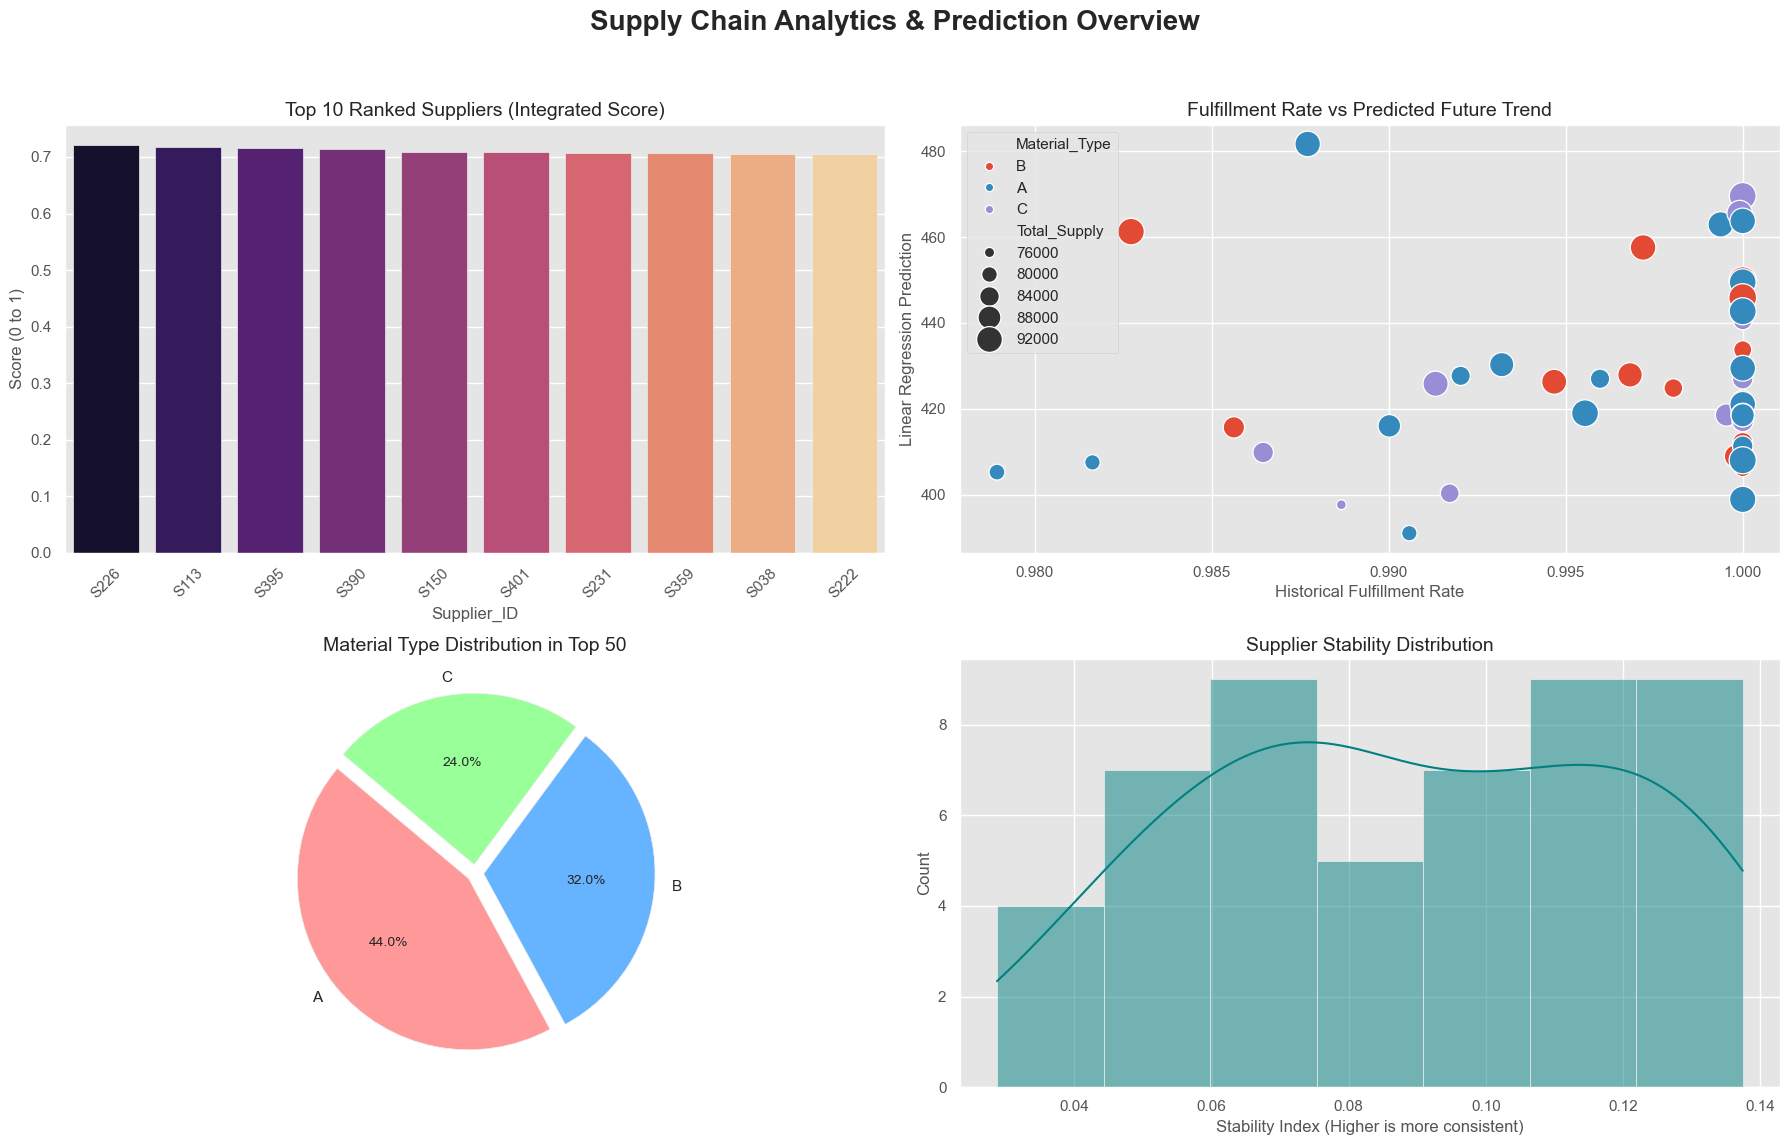

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('ggplot') 
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Supply Chain Analytics & Prediction Overview', fontsize=20, fontweight='bold')


sns.barplot(ax=axes[0, 0], x='Supplier_ID', y='Final_Score', data=top_50.head(10), palette='magma')
axes[0, 0].set_title('Top 10 Ranked Suppliers (Integrated Score)', fontsize=14)
axes[0, 0].set_ylabel('Score (0 to 1)')
axes[0, 0].tick_params(axis='x', rotation=45)


sns.scatterplot(ax=axes[0, 1], x='Fulfillment_Rate', y='Predicted_Trend', 
                hue='Material_Type', size='Total_Supply', data=top_50, sizes=(50, 400))
axes[0, 1].set_title('Fulfillment Rate vs Predicted Future Trend', fontsize=14)
axes[0, 1].set_xlabel('Historical Fulfillment Rate')
axes[0, 1].set_ylabel('Linear Regression Prediction')


top_50['Material_Type'].value_counts().plot.pie(ax=axes[1, 0], autopct='%1.1f%%', 
                                                startangle=140, colors=['#ff9999','#66b3ff','#99ff99'], 
                                                explode=[0.05]*len(top_50['Material_Type'].unique()))
axes[1, 0].set_title('Material Type Distribution in Top 50', fontsize=14)
axes[1, 0].set_ylabel('')

sns.histplot(ax=axes[1, 1], data=top_50, x='Stability_Index', kde=True, color='teal')
axes[1, 1].set_title('Supplier Stability Distribution', fontsize=14)
axes[1, 1].set_xlabel('Stability Index (Higher is more consistent)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()